# **Analisis Kata Kunci dari Ulasan Produk Fashion Wanita di E-Commerce**
### **Nama : Vanessa Alexandra**
### **No : JCDS-2804-014**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Import Library & Load Dataset**

In [2]:
df=pd.read_csv('Womens Clothing E-Commerce Reviews.csv', delimiter=',')
df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


`Clothing ID` : ID unik tiap produk.

`Age` : Usia pelanggan yang memberikan ulasan.

`Title` : Judul singkat dari ulasan.

`Review Text` : Isi lengkap dari ulasan pelanggan.

`Rating` : Skor yang diberikan (1–5).

`Recommended IND` : Apakah pelanggan merekomendasikan produk (1 = ya, 0 = tidak).

`Positive Feedback Count` : Jumlah feedback positif yang diterima dari ulasan tersebut.

`Division Name, Department Name, Class Name` : Kategori produk dalam hierarki organisasi e-commerce tersebut.

Dari dataset tersebut, akan diambil 3 kolom saja, yaitu `Title`, `Review Text`, dan `Rating`. Hal ini dikarenakan:
1. Fokus hanya pada kolom yang berisi teks dan sentimen eksplisit.
2. Menyederhanakan data agar proses pra-pemrosesan dan analisis NLP lebih efisien dan terarah.
3. Menghindari informasi yang kurang relevan (seperti umur, kategori produk, ID produk) karena tujuan utama adalah memahami opini pelanggan melalui teks.

In [3]:
df_nlp = df[['Title','Review Text', 'Rating']].copy()
df_nlp

,Title,Review Text,Rating
0,NaN,Absolutely wonderful - silky and sexy and comf...,4
1,NaN,Love this dress! it's sooo pretty. i happene...,5
2,Some major design flaws,I had such high hopes for this dress and reall...,3
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5
4,Flattering shirt,This shirt is very flattering to all due to th...,5
...,...,...,...
23481,Great dress for many occasions,I was very happy to snag this dress at such a ...,5
23482,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3
23483,"Cute, but see through","This fit well, but the top was very see throug...",3
23484,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3


In [4]:
df_nlp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        19676 non-null  object
 1   Review Text  22641 non-null  object
 2   Rating       23486 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 550.6+ KB


In [5]:
display(df_nlp.describe(), df_nlp.describe(include='object'))

,Rating
count,23486.000000
mean,4.196032
std,1.110031
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


,Title,Review Text
count,19676,22641
unique,13993,22634
top,Love it!,Perfect fit and i've gotten so many compliment...
freq,136,3


In [6]:
df_nlp.isnull().sum()

Title          3810
Review Text     845
Rating            0
dtype: int64

In [7]:
print((df_nlp.isnull().mean() * 100).round(2))

Title          16.22
Review Text     3.60
Rating          0.00
dtype: float64


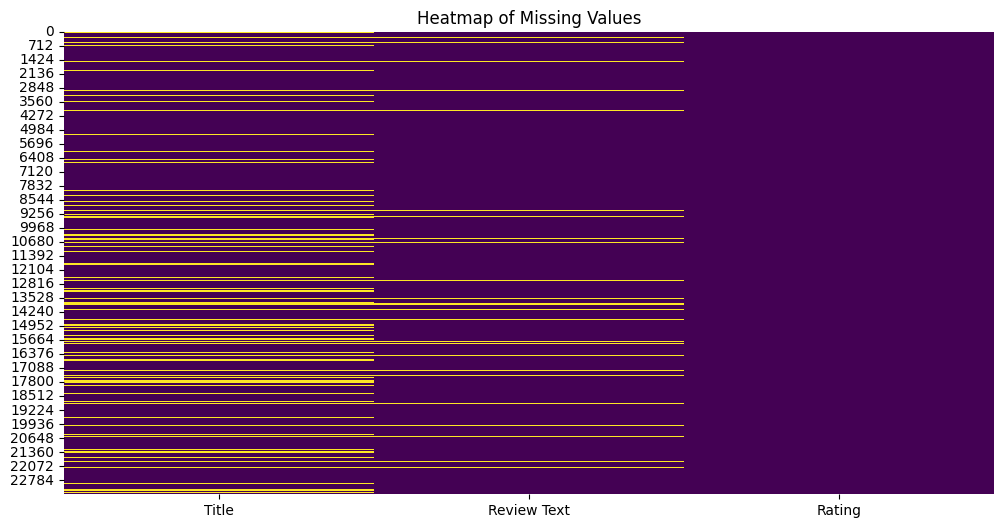

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_nlp.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

In [9]:
df_nlp['Title'].fillna('No Title', inplace=True)
df_nlp['Review Text'].fillna('No Review', inplace=True)
df_nlp

C:\Users\stefa\AppData\Local\Temp\ipykernel_6012\2603224445.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_nlp['Title'].fillna('No Title', inplace=True)
C:\Users\stefa\AppData\Local\Temp\ipykernel_6012\2603224445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

,Title,Review Text,Rating
0,No Title,Absolutely wonderful - silky and sexy and comf...,4
1,No Title,Love this dress! it's sooo pretty. i happene...,5
2,Some major design flaws,I had such high hopes for this dress and reall...,3
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5
4,Flattering shirt,This shirt is very flattering to all due to th...,5
...,...,...,...
23481,Great dress for many occasions,I was very happy to snag this dress at such a ...,5
23482,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3
23483,"Cute, but see through","This fit well, but the top was very see throug...",3
23484,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3


In [10]:
df_nlp.isnull().sum()

Title          0
Review Text    0
Rating         0
dtype: int64

In [11]:
df_nlp.duplicated().sum()

np.int64(844)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df_nlp

,Title,Review Text,Rating
0,No Title,Absolutely wonderful - silky and sexy and comf...,4
1,No Title,Love this dress! it's sooo pretty. i happene...,5
2,Some major design flaws,I had such high hopes for this dress and reall...,3
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5
4,Flattering shirt,This shirt is very flattering to all due to th...,5
...,...,...,...
23481,Great dress for many occasions,I was very happy to snag this dress at such a ...,5
23482,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3
23483,"Cute, but see through","This fit well, but the top was very see throug...",3
23484,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3


# **Text Processing 1**

In [14]:
import re
from string import punctuation
import nltk
from nltk.corpus import stopwords

In [15]:
def to_lower(text):
    return text.lower()

In [16]:
contractions_dict = {
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had",
"he'd've": "he would have",
"he'll": "he will",
"he'll've": "he will have",
"he's": "he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how is",
"I'd": "I had",
"I'd've": "I would have",
"I'll": "I will",
"I'll've": "I will have",
"I'm": "I am",
"I've": "I have",
"isn't": "is not",
"it'd": "it had",
"it'd've": "it would have",
"it'll": "it will",
"it'll've": "iit will have",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had",
"she'd've": "she would have",
"she'll": "she will",
"she'll've": "she will have",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so is",
"that'd": "that had",
"that'd've": "that would have",
"that's": "that is",
"there'd": "there had",
"there'd've": "there would have",
"there's": "there is",
"they'd": "they had",
"they'd've": "they would have",
"they'll": "they will",
"they'll've": "they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what'll've": "what will have",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"when's": "when is",
"when've": "when have",
"where'd": "where did",
"where's": "where is",
"where've": "where have",
"who'll": "who will",
"who'll've": "who will have",
"who's": "who is",
"who've": "who have",
"why's": "why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had",
"you'd've": "you would have",
"you'll": "you will",
"you'll've": "you will have",
"you're": "you are",
"you've": "you have"
}

def expand_contractions(text, contractions_dict):
    contractions_pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())),
                                      flags=re.IGNORECASE | re.DOTALL)

    def expand_match(contraction):
        match = contraction.group(0)
        first_char = match[0]
        expanded_contraction = contractions_dict.get(match) \
            if contractions_dict.get(match) \
            else contractions_dict.get(match.lower())
        expanded_contraction = expanded_contraction
        return expanded_contraction

    expanded_text = contractions_pattern.sub(expand_match, text)
    expanded_text = re.sub("'", "", expanded_text)
    return expanded_text

def main_contraction(text):
    text = expand_contractions(text, contractions_dict)
    return text

In [17]:
def remove_numbers(text):
    output = ''.join(c for c in text if not c.isdigit())
    return output

In [18]:
def remove_punct(text):
    return ''.join(c for c in text if c not in punctuation)

In [19]:
def to_strip(text):
    return " ".join(text.split())

In [20]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\stefa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\stefa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\stefa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [22]:
def remove_stopwords(sentence):
    stop_words = stopwords.words('english')
    return ' '.join([w for w in nltk.word_tokenize(sentence) if not w in stop_words])

In [23]:
pd.options.display.max_colwidth = None

In [24]:
df_nlp['data_prep1'] = df_nlp['Review Text'].apply(to_lower)
df_nlp['data_prep2'] = df_nlp['data_prep1'].apply(main_contraction)
df_nlp['data_prep3'] = df_nlp['data_prep2'].apply(remove_numbers)
df_nlp['data_prep4'] = df_nlp['data_prep3'].apply(remove_punct)
df_nlp['data_prep5'] = df_nlp['data_prep4'].apply(to_strip)
df_nlp['data_prep6'] = df_nlp['data_prep5'].apply(remove_stopwords)
df_nlp

,Title,Review Text,Rating,data_prep1,data_prep2,data_prep3,data_prep4,data_prep5,data_prep6
0,No Title,Absolutely wonderful - silky and sexy and comfortable,4,absolutely wonderful - silky and sexy and comfortable,absolutely wonderful - silky and sexy and comfortable,absolutely wonderful - silky and sexy and comfortable,absolutely wonderful silky and sexy and comfortable,absolutely wonderful silky and sexy and comfortable,absolutely wonderful silky sexy comfortable
1,No Title,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,"love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.","love this dress! it is sooo pretty. i happened to find it in a store, and glad i did bc i never would have ordered it online bc it is petite. i bought a petite and am 58"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.","love this dress! it is sooo pretty. i happened to find it in a store, and glad i did bc i never would have ordered it online bc it is petite. i bought a petite and am "". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",love this dress it is sooo pretty i happened to find it in a store and glad i did bc i never would have ordered it online bc it is petite i bought a petite and am i love the length on me hits just a little below the knee would definitely be a true midi on someone who is truly petite,love this dress it is sooo pretty i happened to find it in a store and glad i did bc i never would have ordered it online bc it is petite i bought a petite and am i love the length on me hits just a little below the knee would definitely be a true midi on someone who is truly petite,love dress sooo pretty happened find store glad bc never would ordered online bc petite bought petite love length hits little knee would definitely true midi someone truly petite
2,Some major design flaws,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",3,"i had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c","i had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c","i had such high hopes for this dr

# **Text Preprocessing 2**

In [25]:
from nltk.stem import SnowballStemmer

In [26]:
snowball_stemmer = SnowballStemmer('english')

def stem(text):
    """
    :param word_tokens:
    :return: list of words
    """
    stemmed_word = [snowball_stemmer.stem(word) for sent in nltk.sent_tokenize(text)for word in nltk.word_tokenize(sent)]
    return " ".join(stemmed_word)

In [27]:
df_nlp['data_stem'] = df_nlp['data_prep6'].apply(stem)

df_nlp[['data_stem']]

,data_stem
0,absolut wonder silki sexi comfort
1,love dress sooo pretti happen find store glad bc never would order onlin bc petit bought petit love length hit littl knee would definit true midi someon truli petit
2,high hope dress realli want work initi order petit small usual size found outrag small small fact could zip reorder petit medium ok overal top half comfort fit nice bottom half tight layer sever somewhat cheap net layer imo major design flaw net layer sewn direct zipper c
3,love love love jumpsuit fun flirti fabul everi time wear get noth great compliment
4,shirt flatter due adjust front tie perfect length wear leg sleeveless pair well cardigan love shirt
...,...
23481,happi snag dress great price easi slip flatter cut color combo
23482,remind matern cloth soft stretchi shini materi cut flatter drape nice found one button close front look awkward nice long sleev mayb other ok
23483,fit well top see never would work glad abl tri store order onlin differ fabric would great
23484,bought dress wed summer cute unfortun fit perfect medium fit waist perfect way long big bust shoulder want spend money could get tailor felt like might worth side note dress deliv nordstrom tag found much cheaper look


# **Text Exploration**
## **Word Frequency**

In [28]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)')
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [29]:
kamus_unclean = kamus(df_nlp['data_stem'])

<Axes: ylabel='kata'>

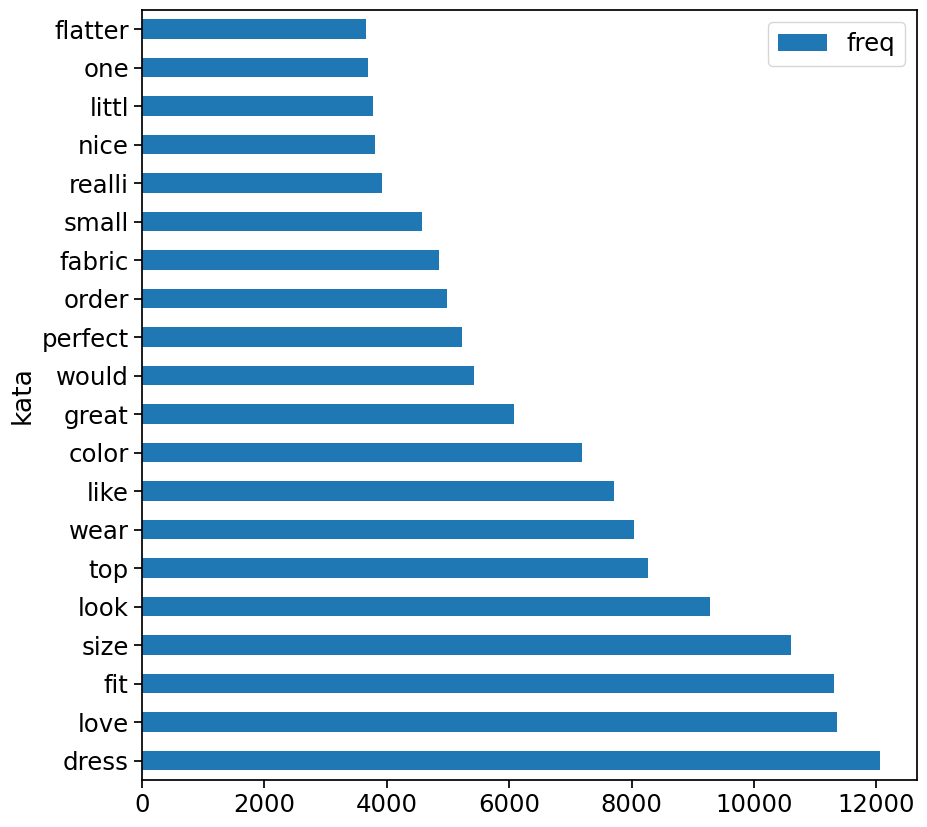

In [30]:
sns.set_context(context = 'notebook', font_scale = 1.6)
kamus_unclean[:20].plot(kind = 'barh',figsize = (10,10))

Secara keseluruhan, kata yang paling sering muncul pada review pelanggan adalah "dress", "love", dan "fit".

## **Word Cloud**

In [31]:
from wordcloud import WordCloud

In [32]:
def plot_cloud(wordcloud):
    # Set figure size
    plt.figure(figsize=(20, 10))
    # Display image
    plt.imshow(wordcloud)
    # No axis details
    plt.axis("off")

In [33]:
word_cloud = WordCloud().generate(str(df_nlp['data_stem']))

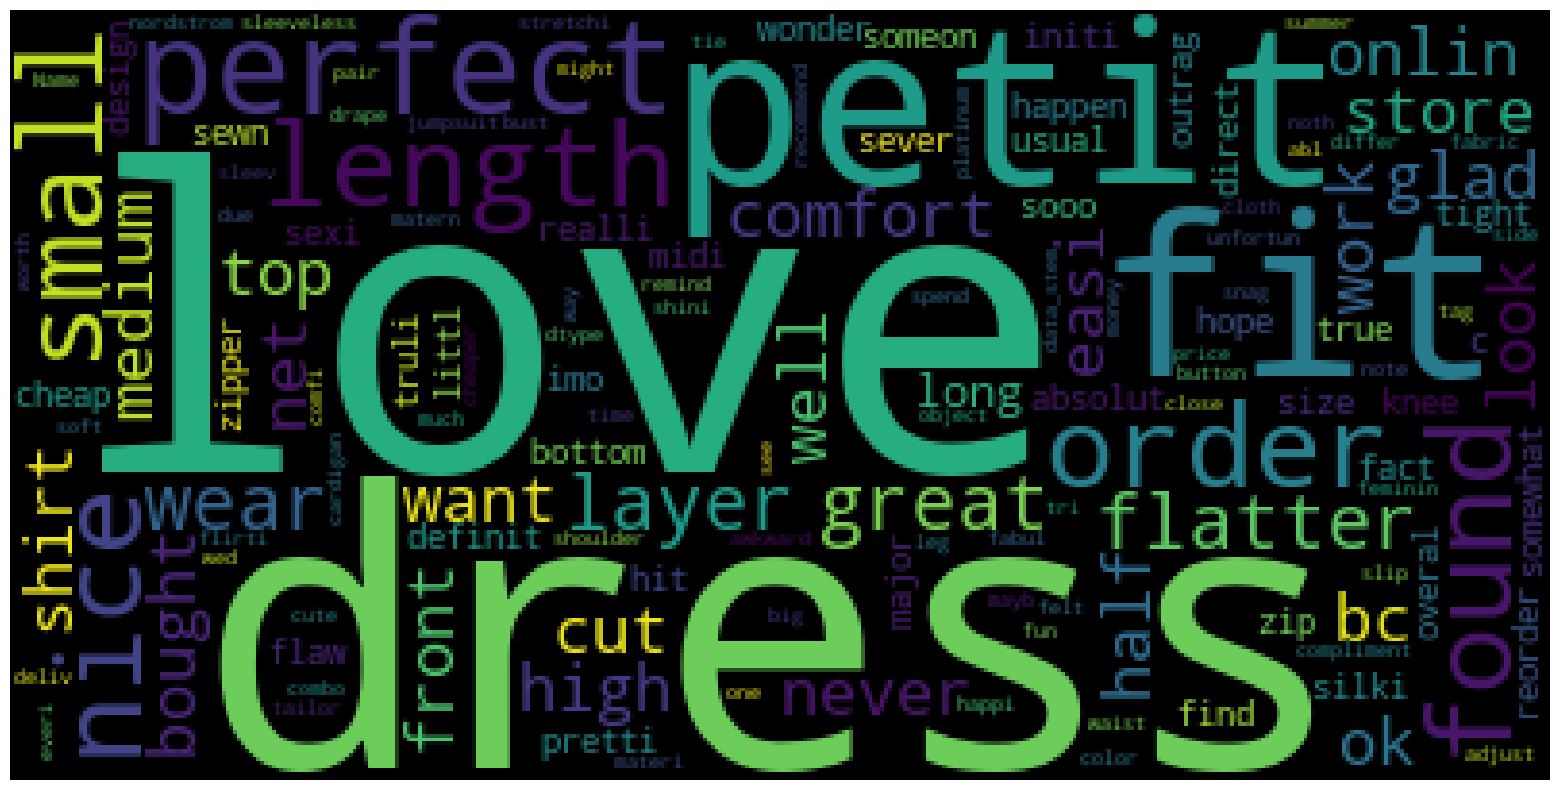

In [34]:
plot_cloud(word_cloud)

Berdasarkan Word Cloud secara keseluruhan di atas, tiga kata yang paling sering muncul adalah "love", "dress", dan "fit".

### **Word Cloud untuk Rating 5**

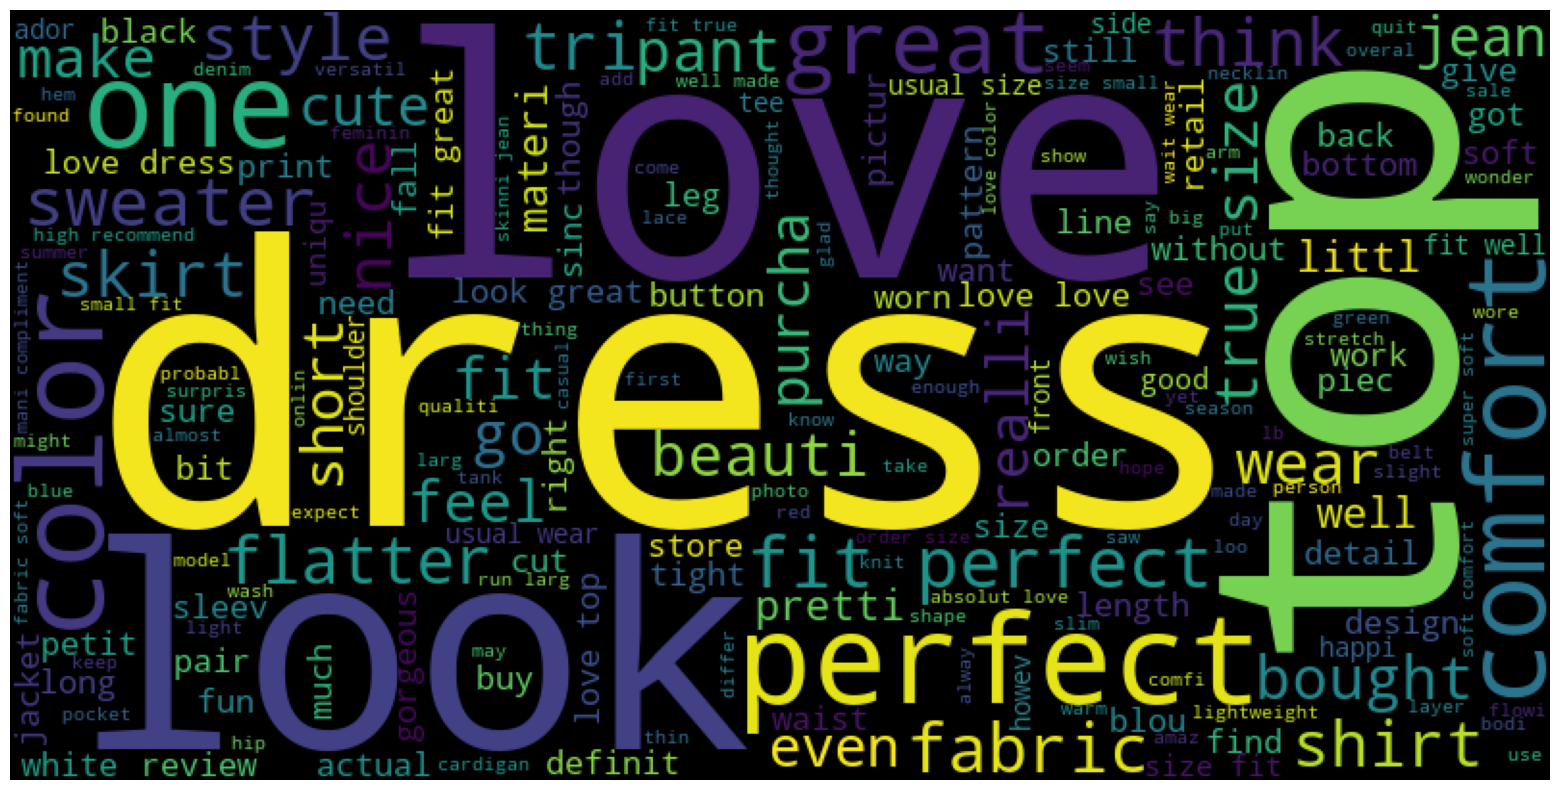

In [35]:
text_rating5 = ' '.join(df_nlp[df_nlp['Rating'] == 5]['data_stem'].dropna().astype(str))
wordcloud_5 = WordCloud(width=800, height=400, background_color='black', colormap='viridis').generate(text_rating5)
plot_cloud(wordcloud_5)

Berdasarkan Word Cloud Review dengan Rating 5, tiga kata yang paling sering muncul adalah "dress", "top", dan "love".

In [36]:
# Filter data Rating 5 yang mengandung kata "dress"
dress_reviews5 = df_nlp[(df_nlp['Rating'] == 5) & (df_nlp['Review Text'].str.contains('dress', case=False, na=False))]

# Filter data Rating 5 yang mengandung kata "top"
top_reviews5 = df_nlp[(df_nlp['Rating'] == 5) & (df_nlp['Review Text'].str.contains('top', case=False, na=False))]

# Filter data Rating 5 yang mengandung kata "love"
love_reviews5 = df_nlp[(df_nlp['Rating'] == 5) & (df_nlp['Review Text'].str.contains('love', case=False, na=False))]

# Lihat beberapa contohnya
print("Review tentang 'dress':")
print(dress_reviews5['Review Text'].head(5))

print("\nReview tentang 'top':")
print(top_reviews5['Review Text'].head(5))

print("\nReview tentang 'love':")
print(love_reviews5['Review Text'].head(5))

Review tentang 'dress':
1                                                                                                                                                                                                            Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i bought a petite and am 5'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.
8                                                                                                                                                                                                                                                                                                                                                     I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine

### **Word Cloud untuk Rating 4**

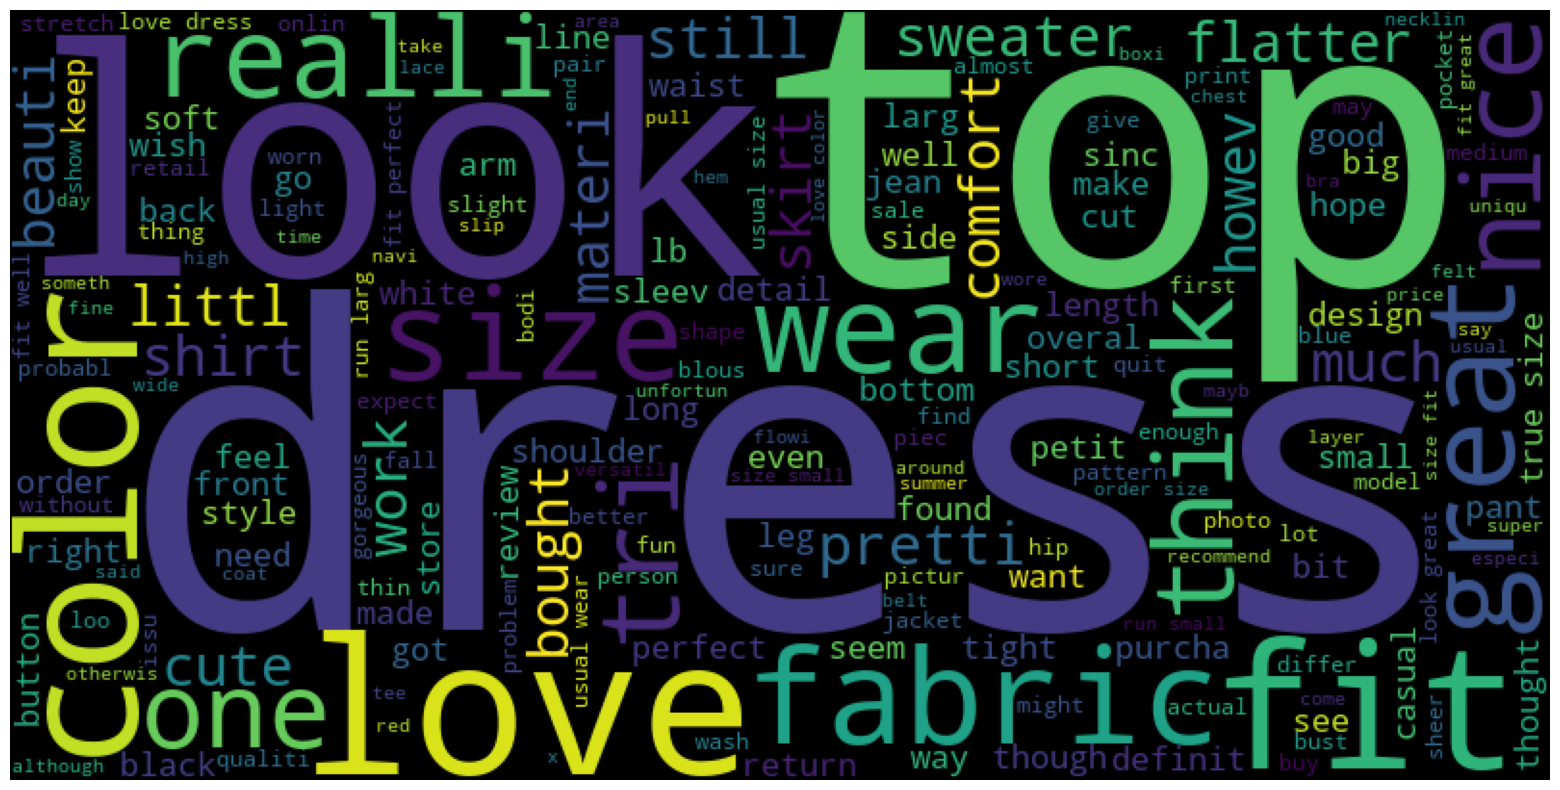

In [37]:
text_rating4 = ' '.join(df_nlp[df_nlp['Rating'] == 4]['data_stem'].dropna().astype(str))
wordcloud_4 = WordCloud(width=800, height=400, background_color='black', colormap='viridis').generate(text_rating4)
plot_cloud(wordcloud_4)

Berdasarkan Word Cloud Review dengan Rating 4, tiga kata yang paling sering muncul adalah "dress", "top", dan "look".

In [38]:
# Filter data Rating 4 yang mengandung kata "dress"
dress_reviews4 = df_nlp[(df_nlp['Rating'] == 4) & (df_nlp['Review Text'].str.contains('dress', case=False, na=False))]

# Filter data Rating 4 yang mengandung kata "top"
top_reviews4 = df_nlp[(df_nlp['Rating'] == 4) & (df_nlp['Review Text'].str.contains('top', case=False, na=False))]

# Filter data Rating 4 yang mengandung kata "look"
look_reviews4 = df_nlp[(df_nlp['Rating'] == 4) & (df_nlp['Review Text'].str.contains('look', case=False, na=False))]

# Lihat beberapa contohnya
print("Review tentang 'dress':")
print(dress_reviews4['Review Text'].head(5))

print("\nReview tentang 'top':")
print(top_reviews4['Review Text'].head(5))

print("\nReview tentang 'look':")
print(look_reviews4['Review Text'].head(5))

Review tentang 'dress':
21    I'm upset because for the price of the dress, i thought it was embroidered! no, that is a print on the fabric. i think i cried a little when i opened the box. it is still ver pretty. i would say it is true to size, it is a tad bit big on me, but i am very tiny, but i can still get away with it. the color is vibrant. the style is unique. skirt portion is pretty poofy. i keep going back and forth on it mainly because of the price, although the quality is definitely there. except i wish it were emb
76                                                                                                                                                                                                                              I would have loved this dress if the bust and waist were just a little more fitted. i am 32c and the top was too big. fit perfectly on hips. the lace material means it cannot be easily altered, so i chose to return the dress. i would have defini

### **Word Cloud untuk Rating 3**

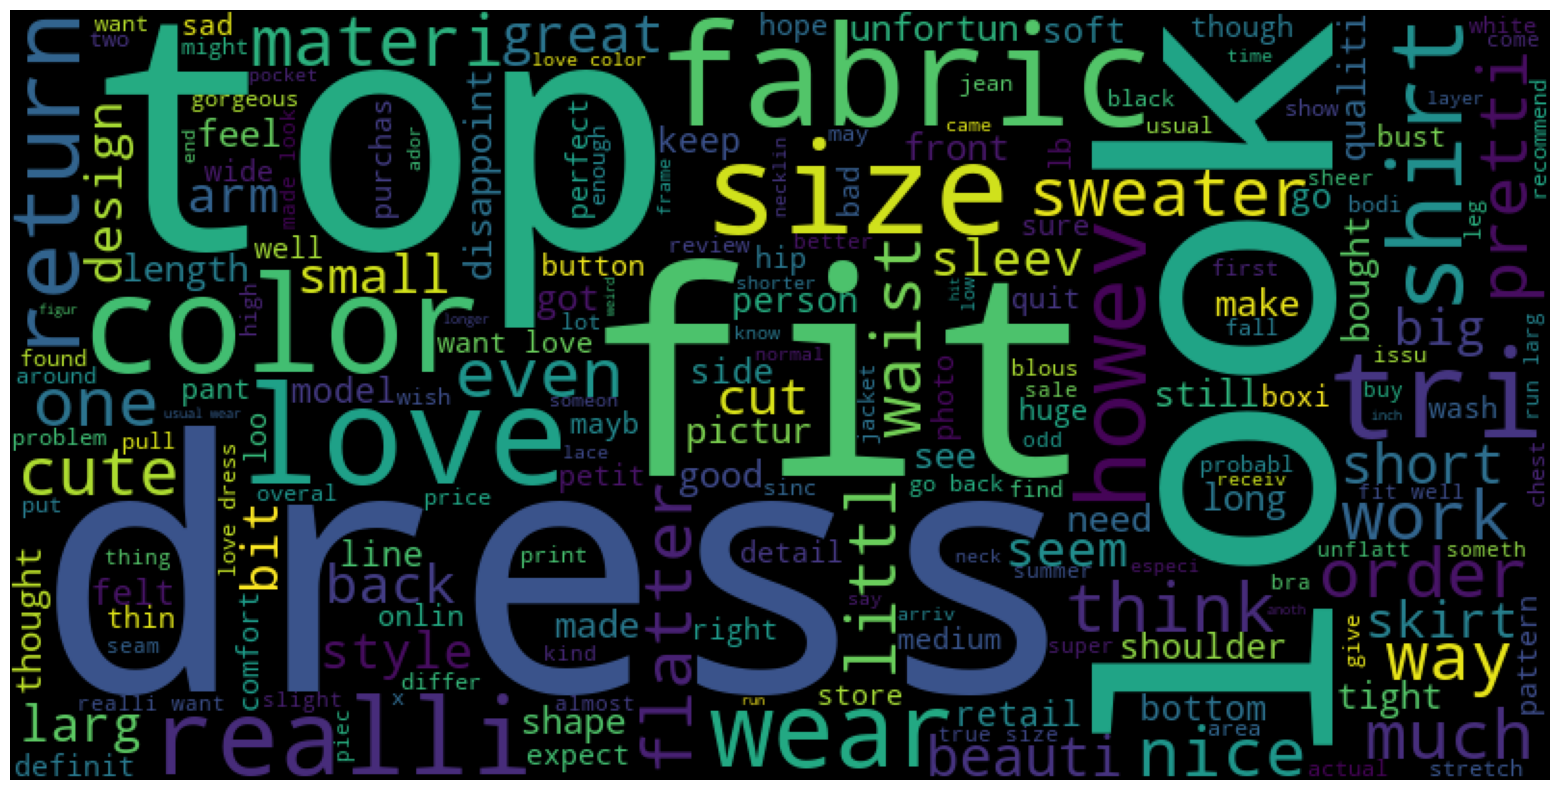

In [39]:
text_rating3 = ' '.join(df_nlp[df_nlp['Rating'] == 3]['data_stem'].dropna().astype(str))
wordcloud_3 = WordCloud(width=800, height=400, background_color='black', colormap='viridis').generate(text_rating3)
plot_cloud(wordcloud_3)

Berdasarkan Word Cloud Review dengan Rating 3, tiga kata yang paling sering muncul adalah "dress", "top", dan "look".

In [40]:
# Filter data Rating 3 yang mengandung kata "dress"
dress_reviews3 = df_nlp[(df_nlp['Rating'] == 3) & (df_nlp['Review Text'].str.contains('dress', case=False, na=False))]

# Filter data Rating 3 yang mengandung kata "top"
top_reviews3 = df_nlp[(df_nlp['Rating'] == 3) & (df_nlp['Review Text'].str.contains('top', case=False, na=False))]

# Filter data Rating 3 yang mengandung kata "look"
look_reviews3 = df_nlp[(df_nlp['Rating'] == 3) & (df_nlp['Review Text'].str.contains('look', case=False, na=False))]

# Lihat beberapa contohnya
print("Review tentang 'dress':")
print(dress_reviews3['Review Text'].head(5))

print("\nReview tentang 'top':")
print(top_reviews3['Review Text'].head(5))

print("\nReview tentang 'look':")
print(look_reviews3['Review Text'].head(5))

Review tentang 'dress':
2     I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c
10                                                                                                                                                                        Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the material on the top looks and feels very cheap that even just pulling on it will cause it to rip the fabric. pretty disappointed as it was going to be my christmas dress this year! n

### **Word Cloud untuk Rating 2**

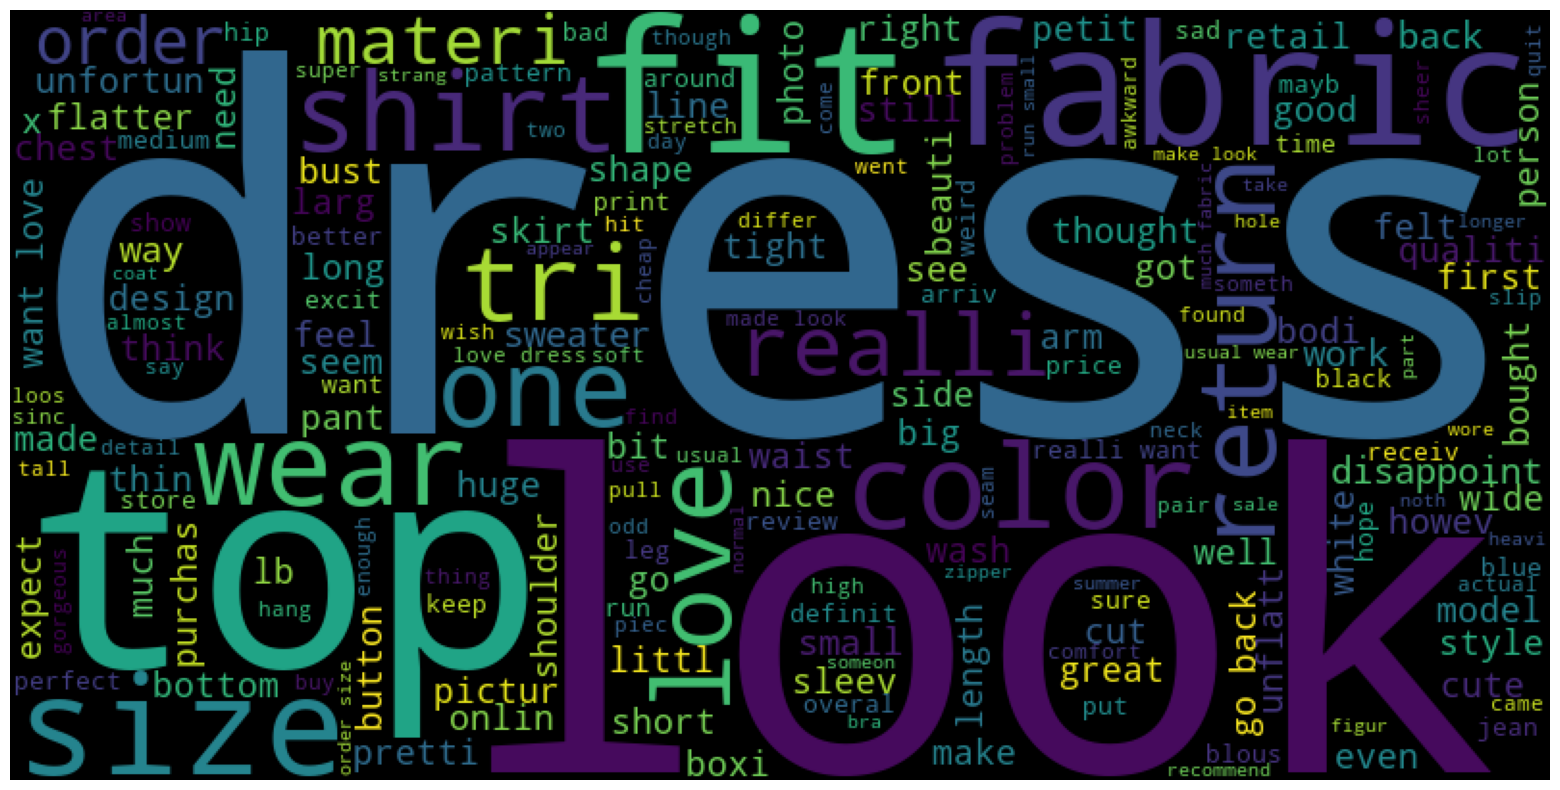

In [41]:
text_rating2 = ' '.join(df_nlp[df_nlp['Rating'] == 2]['data_stem'].dropna().astype(str))
wordcloud_2 = WordCloud(width=800, height=400, background_color='black', colormap='viridis').generate(text_rating2)
plot_cloud(wordcloud_2)

Berdasarkan Word Cloud Review dengan Rating 2, tiga kata yang paling sering muncul adalah "dress", "look", dan "top".

In [42]:
# Filter data Rating 2 yang mengandung kata "dress"
dress_reviews2 = df_nlp[(df_nlp['Rating'] == 2) & (df_nlp['Review Text'].str.contains('dress', case=False, na=False))]

# Filter data Rating 2 yang mengandung kata "top"
top_reviews2 = df_nlp[(df_nlp['Rating'] == 2) & (df_nlp['Review Text'].str.contains('top', case=False, na=False))]

# Filter data Rating 2 yang mengandung kata "look"
look_reviews2 = df_nlp[(df_nlp['Rating'] == 2) & (df_nlp['Review Text'].str.contains('look', case=False, na=False))]

# Lihat beberapa contohnya
print("Review tentang 'dress':")
print(dress_reviews2['Review Text'].head(5))

print("\nReview tentang 'top':")
print(top_reviews2['Review Text'].head(5))

print("\nReview tentang 'look':")
print(look_reviews2['Review Text'].head(5))

Review tentang 'dress':
5                    I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress. the skirt is long and very full so it overwhelmed my small frame. not a stranger to alterations, shortening and narrowing the skirt would take away from the embellishment of the garment. i love the color and the idea of the style but it just did not work on me. i returned this dress.
114         The design/shape of the dress are quite flattering, flirty and feminine. but.... there is no way that the dress i received is new. the color is a faded washed out red and there are black stains all over the belt area. there is no tag... the fabric looks droopy and laundered and is not crisp, stiff or new. i am very disappointed by the quality of the item that i received. undoubtedly this one is going back.\n\ndear retailer - please make sure that you

### **Word Cloud untuk Rating 1**

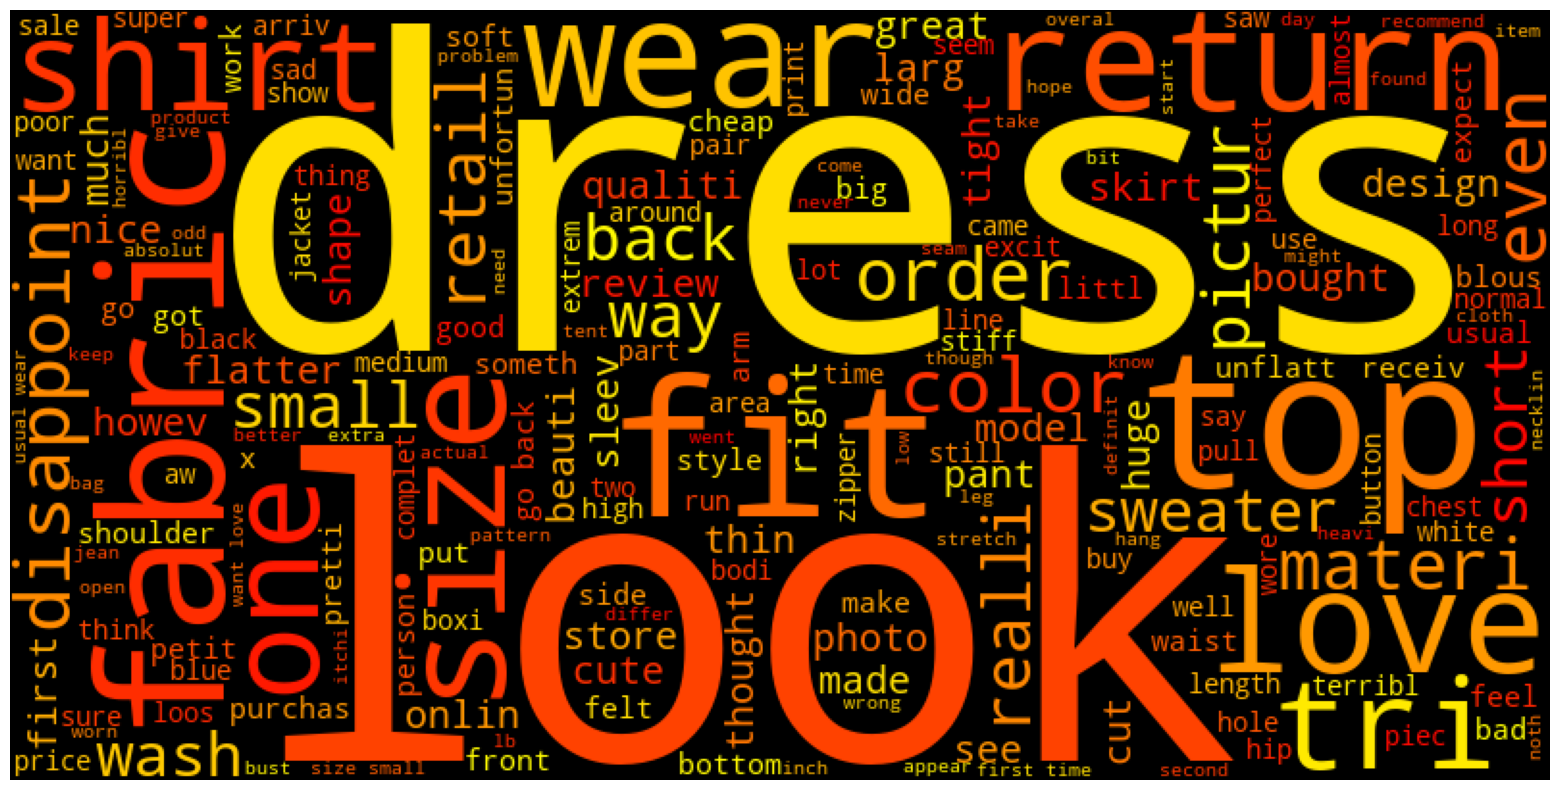

In [43]:
text_rating1 = ' '.join(df_nlp[df_nlp['Rating'] == 1]['data_stem'].dropna().astype(str))
wordcloud_1 = WordCloud(width=800, height=400, background_color='black', colormap='autumn').generate(text_rating1)
plot_cloud(wordcloud_1)

Berdasarkan Word Cloud Review dengan Rating 1, tiga kata yang paling sering muncul adalah "dress", "look", dan "top".

In [44]:
# Filter data Rating 1 yang mengandung kata "dress"
dress_reviews1 = df_nlp[(df_nlp['Rating'] == 1) & (df_nlp['Review Text'].str.contains('dress', case=False, na=False))]

# Filter data Rating 1 yang mengandung kata "top"
top_reviews1 = df_nlp[(df_nlp['Rating'] == 1) & (df_nlp['Review Text'].str.contains('top', case=False, na=False))]

# Filter data Rating 1 yang mengandung kata "look"
look_reviews1 = df_nlp[(df_nlp['Rating'] == 1) & (df_nlp['Review Text'].str.contains('look', case=False, na=False))]

# Filter data Rating 1 yang mengandung kata "fit"
fit_reviews1 = df_nlp[(df_nlp['Rating'] == 1) & (df_nlp['Review Text'].str.contains('fit', case=False, na=False))]

# Lihat beberapa contohnya
print("Review tentang 'dress':")
print(dress_reviews1['Review Text'].head(5))

print("\nReview tentang 'top':")
print(top_reviews1['Review Text'].head(5))

print("\nReview tentang 'look':")
print(look_reviews1['Review Text'].head(5))

print("\nReview tentang 'fit':")
print(fit_reviews1['Review Text'].head(5))

Review tentang 'dress':
96                                                                                                                                                                                                                                                                           I usually wear a medium and bought a small. it fit ok, but had no shape and was not flattering. i love baby doll dresses and tops, but this was a tent. my daughter saw me try it on and said "that's a piece of tablecloth." it's going back.
241    I loved this dress from the moment i tried it on. so flattering to my postpartum body without being a huge tent. soft fabric, and for a white/lightly striped dress, not sheer. i'm bummed because after washing only twice (followed the instructions to wash) on gentle cycle and low tumble dry, holes started appearing everywhere, both on the cream ribbed hem in the front bottom and all across the chest, in the white part of the fabric only (it looks like the bl

## **Length of Sentence**

In [45]:
df_nlp['length'] = df_nlp['Review Text'].apply(len)

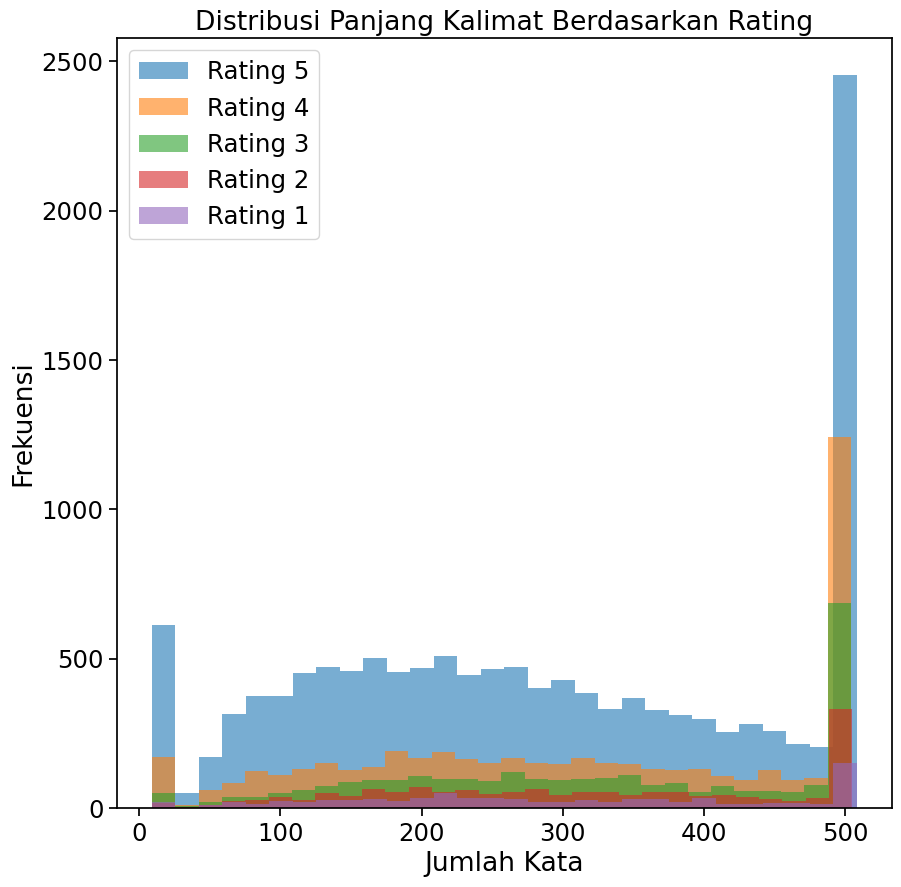

In [49]:
plt.figure(figsize=(10, 10))
df_nlp[df_nlp['Rating'] == 5]['length'].plot(kind='hist', alpha=0.6, bins=30, label='Rating 5')
df_nlp[df_nlp['Rating'] == 4]['length'].plot(kind='hist', alpha=0.6, bins=30, label='Rating 4')
df_nlp[df_nlp['Rating'] == 3]['length'].plot(kind='hist', alpha=0.6, bins=30, label='Rating 3')
df_nlp[df_nlp['Rating'] == 2]['length'].plot(kind='hist', alpha=0.6, bins=30, label='Rating 2')
df_nlp[df_nlp['Rating'] == 1]['length'].plot(kind='hist', alpha=0.6, bins=30, label='Rating 1')
plt.legend()
plt.title("Distribusi Panjang Kalimat Berdasarkan Rating")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

Berdasarkan chart di atas, dapat dilihat bahwa pelanggan yang memberikan Rating 5 cenderung memberikan ulasan yang lebih panjang dibandingkan pelanggan yang memberikan Rating 1.

## **Kesimpulan**

Berdasarkan analisis di atas, kita tahu bahwa secara keseluruhan kata yang paling sering muncul ialah "love", "dress", dan "fit". Setelah diteliti berdasarkan Rating, diperoleh hasil sebagai berikut:
1. Berdasarkan Rating 5, kata yang paling sering muncul adalah "dress", "top", dan "love". Dapat disimpulkan bahwa banyak pelanggan yang mencintai produk fashion kita, terutama untuk dress dan atasan (top).
2. Berdasarkan Rating 4, Rating 3, dan Rating 2, kata yang paling sering muncul adalah "dress", "top", dan "look". Dapat disimpulkan bahwa sebagian pelanggan kurang menyukai looknya, sebagian menyukai looknya, sebagian menyukai dressnya, sebagian kurang menyukai dressnya, sebagian menyukai topnya, dan sebagian kurang menyukai topnya.
2. Berdasarkan Rating 1, kata yang paling sering muncul adalah "dress", "look", dan "top". Dapat disimpulkan bahwa banyak pelanggan yang kurang menyukai produk fashion kita dikarenakan penampilannya (look). Selain itu, beberapa ada juga yang kurang menyukai dress dan atasannya (top).

Dengan demikian, perusahaan dapat melakukan improvement pada produk dress dan top supaya pelanggan yang memberikan Rating 5 semakin menyukai produk perusahaan tersebut dan pelanggan yang memberikan Rating 1 bisa mulai menyukai produk yang dibuat.

## Import to Bigquery

In [47]:
from google.cloud import bigquery
from pandas.io import gbq
from google.oauth2 import service_account
import pandas_gbq

In [48]:
project_id = 'portfolio-project-module-02'
dataset_id = 'dataset_womens_clothing_ecommerce'
table_name = 'womens_clothing_ecommerce'
key_path = r"C:\Users\stefa\OneDrive\Documents\VANESSA\PURWADHIKA SCHOOL JAN-MEI 2025\MODUL 02\Hands On\ETL - Google Big Query\portfolio-project-module-02-bb953a6df2b4.json"

scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

pandas_gbq.to_gbq(df_nlp, 
                  f'{dataset_id}.{table_name}',
                  project_id=project_id, 
                  if_exists='replace', 
                  credentials=credentials)

100%|██████████| 1/1 [00:00<00:00, 7928.74it/s]
